In [48]:
from google.colab import files
uploaded=files.upload()

Saving spam.csv to spam (1).csv


In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle

**Step 2 - Load Dataset**

In [74]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')

In [75]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


**Step 3 - Remove Unnecessary Columns**

In [77]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Step 4 - Check Missing Values**

In [78]:
df.isnull().sum()

,0
label,0
message,0


**Step 5 - Check Duplicate Messages**

In [79]:
df.duplicated().sum()

np.int64(403)

In [80]:
df = df.drop_duplicates()

**Step 6 - Label Encoding**

In [81]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

**Step 7 - Explore Dataset**

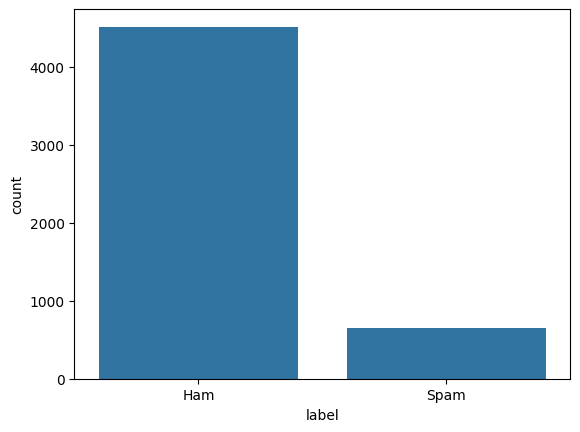

In [82]:
sns.countplot(x=df['label'])
plt.xticks([0,1],['Ham','Spam'])
plt.show()

In [83]:
df['label'].value_counts()

,count
label,
0,4516
1,653


**Step 8 - Download NLTK**

In [92]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

**Step 9 - Text Cleaning Function**

In [89]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [90]:
def transform_text(text):

    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

**Step 10 - Clean Messages**

In [93]:
df['transformed_message'] = df['message'].apply(transform_text)

In [94]:
df.head()

,label,message,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


**Step 11 - TF-IDF Vectorization**

In [95]:
tfidf = TfidfVectorizer(max_features=3000)

In [96]:
X = tfidf.fit_transform(df['transformed_message']).toarray()

y = df['label']


**Step 12 - Train Test Split**

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 13 - Train Model**

In [98]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

**Step 14 - Predictions**

In [99]:
y_pred = model.predict(X_test)

**Step 15 - Accuracy**

In [100]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.9729206963249516


**Step 16 - Confusion Matrix**

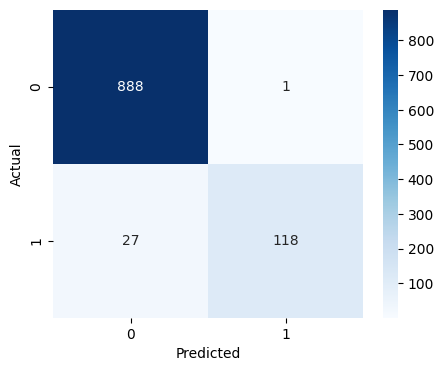

In [101]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Step 17 - Classification Report**

In [102]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



**Step 18 - Test Your Own SMS**

In [103]:
sms = "Congratulations! You have won a FREE iPhone. Click the link now."

clean = transform_text(sms)

vector = tfidf.transform([clean])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam


In [104]:
pickle.dump(model,open('model.pkl','wb'))
pickle.dump(tfidf,open('vectorizer.pkl','wb'))

from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>